In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import Sampler, QiskitRuntimeService


# Exercise 1

In [3]:
bell_circuit = QuantumCircuit(2, 2)
bell_circuit.h(0)
bell_circuit.cx(0, 1)
bell_circuit.measure([0, 1], [0, 1])

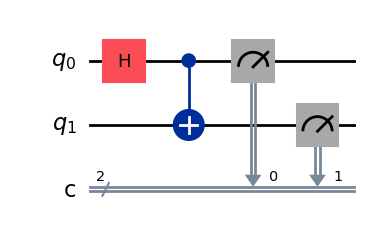

In [4]:
bell_circuit.draw('mpl')

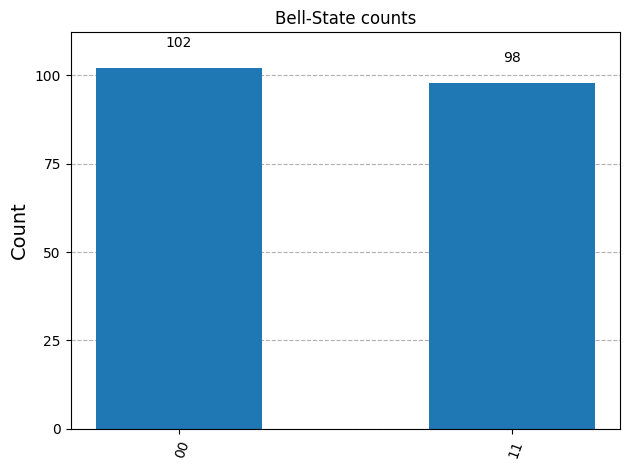

In [5]:
# qasm simulator chosen
simulator = Aer.get_backend('qasm_simulator')

# Transpile
bell_circuit_transpiled = transpile(bell_circuit, simulator)

# Execute and results
job = simulator.run(bell_circuit_transpiled, shots=200, memory=True)
result = job.result()
counts = result.get_counts()
plot_histogram(counts, title='Bell-State counts')



In [6]:
shots = 200
prob_00 = counts.get('00', 0) / shots
prob_11 = counts.get('11', 0) / shots

print(f"Probability of 00: {prob_00:.3f}")
print(f"Probability of 11: {prob_11:.3f}")

Probability of 00: 0.510
Probability of 11: 0.490


As it could be seen in the underneath results, as the quantum circuits measures the Bell State phi + , the chances of getting 00 and 11 are the same, in fact, the more we increase the number of shots, the more even the distribution is, satisfying the Big Number's Law. The probabilities of obtaining 00 and 11 given the distribution resulted by the sampler tend to be even (0.5)

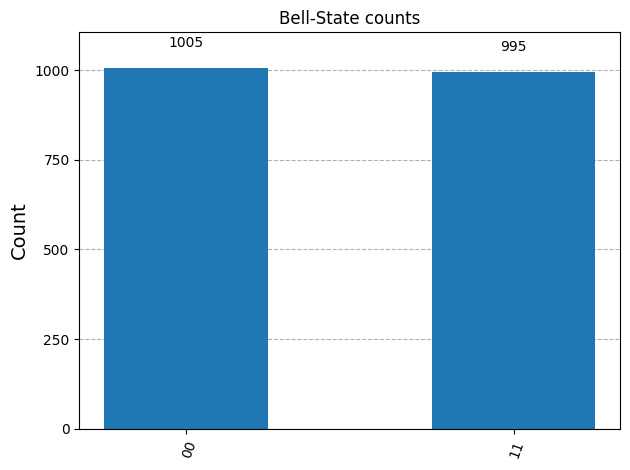

In [7]:
# Execute and results
job = simulator.run(bell_circuit_transpiled, shots=2000, memory=True)
result = job.result()
counts = result.get_counts()
plot_histogram(counts, title='Bell-State counts')

In [8]:
shots = 2000
prob_00 = counts.get('00', 0) / shots
prob_11 = counts.get('11', 0) / shots

print(f"Probability of 00: {prob_00:.3f}")
print(f"Probability of 11: {prob_11:.3f}")

Probability of 00: 0.502
Probability of 11: 0.497


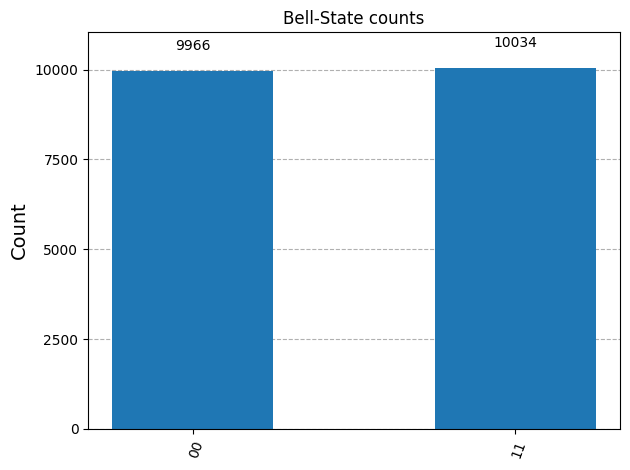

In [9]:
# Execute and results
job = simulator.run(bell_circuit_transpiled, shots=20000, memory=True)
result = job.result()
counts = result.get_counts()
plot_histogram(counts, title='Bell-State counts')

In [10]:
shots = 20000
prob_00 = counts.get('00', 0) / shots
prob_11 = counts.get('11', 0) / shots

print(f"Probability of 00: {prob_00:.3f}")
print(f"Probability of 11: {prob_11:.3f}")

Probability of 00: 0.498
Probability of 11: 0.502


# Exercise 2

Let's connect to my IBM cloud environment using the TOKEN

In [12]:
service = QiskitRuntimeService(channel="ibm_quantum_platform", token="8H6e3kMDOmCJI9GaXulCI5Kb2e3V6avQCbHZrAOUc-UT")

qiskit_runtime_service._discover_account:WARNING:2026-02-01 20:57:06,344: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-02-01 20:57:08,851: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Below we can see the available backends at the moment.

In [13]:
service.backends(simulator=False, operational=True)

qiskit_runtime_service.backends:WARNING:2026-02-01 20:57:30,310: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_torino')>,
 <IBMBackend('ibm_marrakesh')>]

These three are accesible backends right now, let's choose for instance ibm_fez and ibm_torino.

In [14]:
backend_fez = service.backend('ibm_fez')
backend_torino = service.backend('ibm_torino')

qiskit_runtime_service.backends:WARNING:2026-02-01 20:57:35,379: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-01 20:57:35,382: Using instance: open-instance, plan: open


Before running it into this 2 different backends, we need to transpile the original circuit.

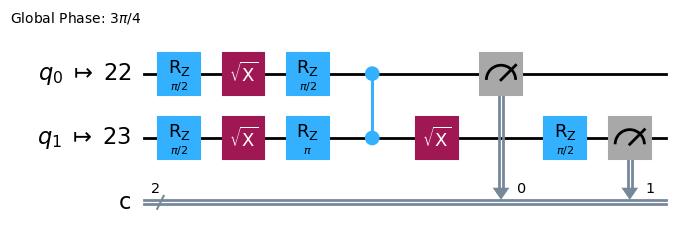

In [15]:
transpiled_fez = transpile(bell_circuit, backend=backend_fez)
transpiled_fez.draw('mpl')

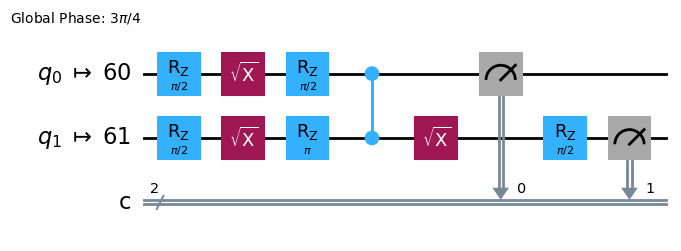

In [16]:
transpiled_torino = transpile(bell_circuit, backend=backend_torino)
transpiled_torino.draw('mpl')

In [17]:
backend_fez.configuration().to_dict()

{'backend_name': 'ibm_fez',
 'backend_version': '1.3.30',
 'n_qubits': 156,
 'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
 'gates': [{'name': 'id',
   'parameters': [],
   'qasm_def': 'gate id q { U(0, 0, 0) q; }',
   'coupling_map': [[0],
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10],
    [11],
    [12],
    [13],
    [14],
    [15],
    [16],
    [17],
    [18],
    [19],
    [20],
    [21],
    [22],
    [23],
    [24],
    [25],
    [26],
    [27],
    [28],
    [29],
    [30],
    [31],
    [32],
    [33],
    [34],
    [35],
    [36],
    [37],
    [38],
    [39],
    [40],
    [41],
    [42],
    [43],
    [44],
    [45],
    [46],
    [47],
    [48],
    [49],
    [50],
    [51],
    [52],
    [53],
    [54],
    [55],
    [56],
    [57],
    [58],
    [59],
    [60],
    [61],
    [62],
    [63],
    [64],
    [65],
    [66],
    [67],
    [68],
    [69],
    [70],
    [71],
    [72],
    [73],
    [74],
    [75],
    [76],
    [77]

In [18]:
backend_torino.configuration().to_dict()

{'backend_name': 'ibm_torino',
 'backend_version': '1.0.107',
 'n_qubits': 133,
 'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
 'gates': [{'name': 'id',
   'parameters': [],
   'qasm_def': 'gate id q { U(0, 0, 0) q; }',
   'coupling_map': [[0],
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10],
    [11],
    [12],
    [13],
    [14],
    [15],
    [16],
    [17],
    [18],
    [19],
    [20],
    [21],
    [22],
    [23],
    [24],
    [25],
    [26],
    [27],
    [28],
    [29],
    [30],
    [31],
    [32],
    [33],
    [34],
    [35],
    [36],
    [37],
    [38],
    [39],
    [40],
    [41],
    [42],
    [43],
    [44],
    [45],
    [46],
    [47],
    [48],
    [49],
    [50],
    [51],
    [52],
    [53],
    [54],
    [55],
    [56],
    [57],
    [58],
    [59],
    [60],
    [61],
    [62],
    [63],
    [64],
    [65],
    [66],
    [67],
    [68],
    [69],
    [70],
    [71],
    [72],
    [73],
    [74],
    [75],
    [76],
    

# Exercise 3

Let's run the circuit on the least busy backend, which is ibm_fez

In [19]:
backend = service.least_busy(operational=True, simulator=False)
print(backend)

qiskit_runtime_service.backends:WARNING:2026-02-01 20:58:43,979: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-01 20:58:45,493: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


Let's run the circuit.

In [20]:
sampler = Sampler(mode=backend_fez)
job = sampler.run([transpiled_fez])

Let's check that the job is completed.

In [24]:
job.status()

'DONE'

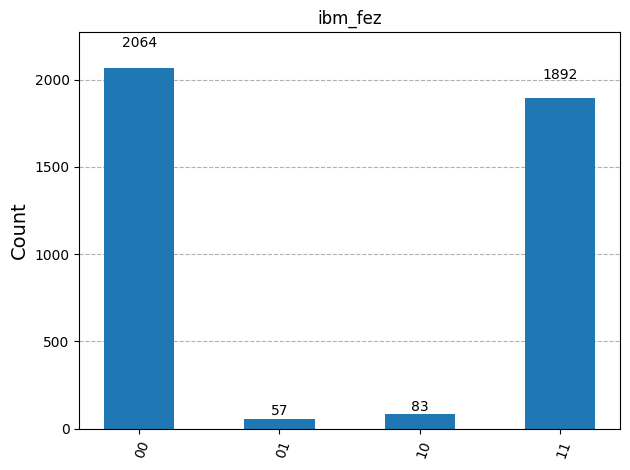

In [ ]:
counts = job.result()[0].data.c.get_counts()
plot_histogram(counts,title=f'{backend.name}')

As we can see, the two most retrieved results are 00 an 11 as expected, but we can also see that the measurements have given 01 and 10. This is explained due to the noise on the calculations of the quantum computer.

# Exercise 4

Let's get the bell state by using the custom initialization provided by Qiskit. First, let's define the Bell State.

In [26]:
import numpy as np
bell =np.array( [1.+0.j, 0. +0.j, 0.+0.j,1.+0.j])/np.sqrt(2)

Now let's use the initilization function provided by Qiskit.

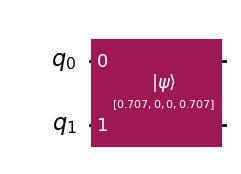

In [27]:
bell_circuit2 = QuantumCircuit(2)
bell_circuit2.initialize(bell) 
bell_circuit2.draw('mpl')